In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"D:\Ameng\Data Science Project\heart-failure-prediction\data\heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [5]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [10]:
print("Target distribution:")
print(df['DEATH_EVENT'].value_counts())
print("\nTarget percentage:")
print(df['DEATH_EVENT'].value_counts(normalize=True) * 100)

Target distribution:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Target percentage:
DEATH_EVENT
0    67.892977
1    32.107023
Name: proportion, dtype: float64


C:\Users\akmal\AppData\Local\Temp\ipykernel_7084\3436634790.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Death (1)", "Survived (0)"])


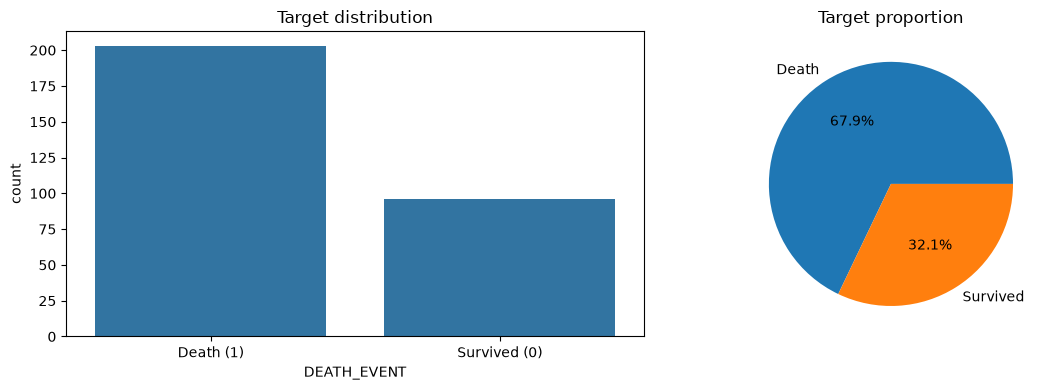

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(data=df, x="DEATH_EVENT", ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xticklabels(["Death (1)", "Survived (0)"])

df["DEATH_EVENT"].value_counts().plot(kind="pie",
                                    labels=["Death", "Survived"],
                                    autopct="%1.1f%%",
                                    ax=axes[1])
axes[1].set_title("Target proportion")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

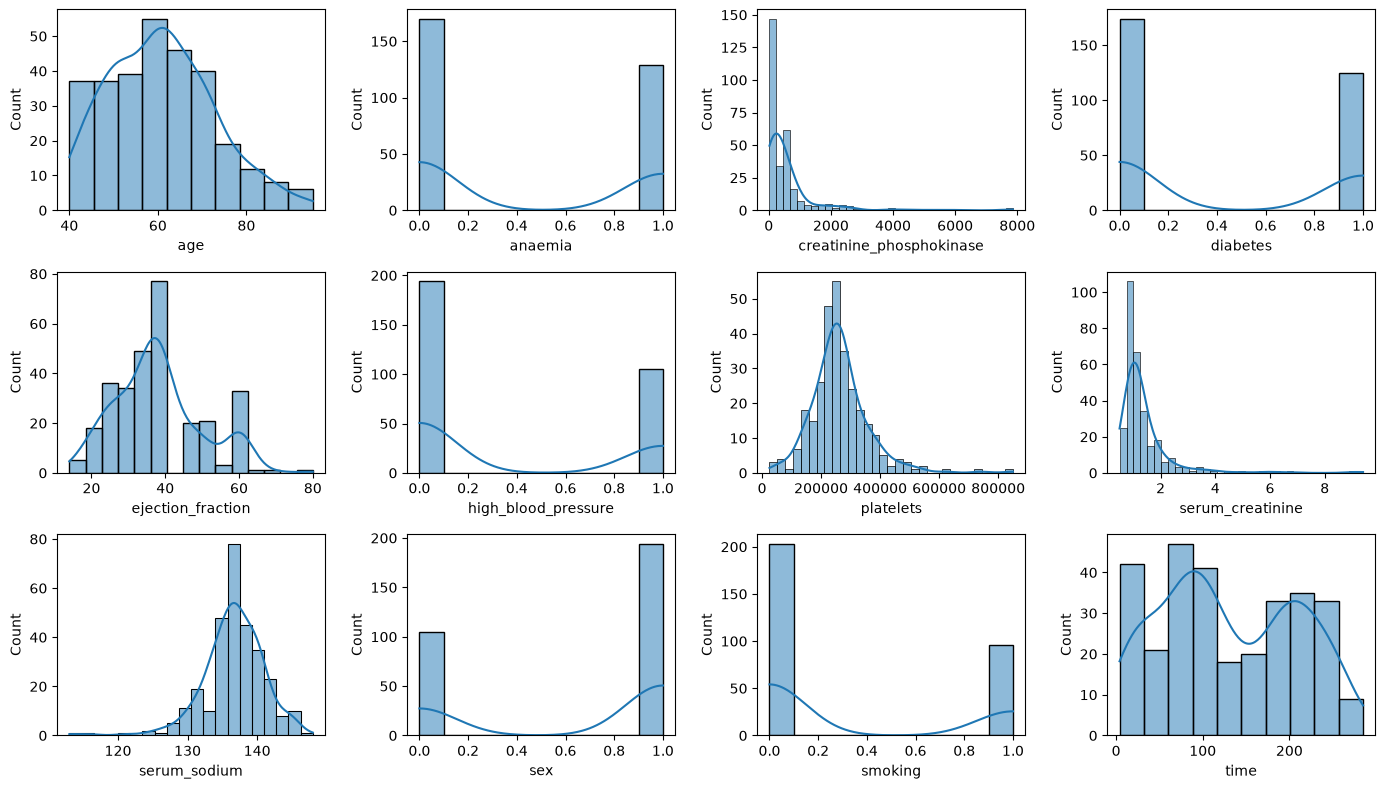

In [49]:
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
axes = axes.flatten()
i = 0
for column in df:
    if column != "DEATH_EVENT":
        sns.histplot(df[column], kde=True, ax=axes[i])
        axes[i].set_xlabel(column)
        i += 1

plt.tight_layout()
plt.show()

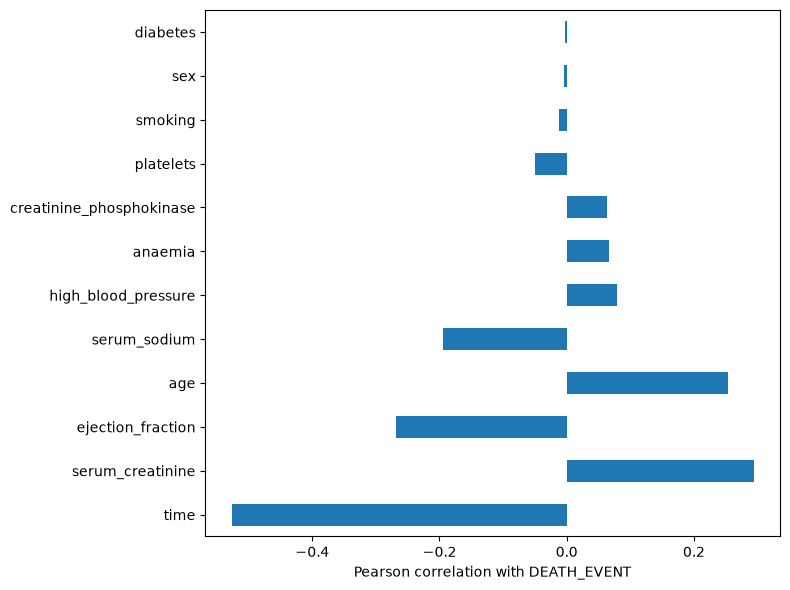

In [53]:
corr = df.corr()["DEATH_EVENT"].sort_values(key=abs, ascending=False)
corr.drop("DEATH_EVENT").plot(kind="barh", figsize=(8, 6))
plt.xlabel("Pearson correlation with DEATH_EVENT")
plt.tight_layout()
plt.show()